# Clasificación de Imágenes con PyTorch
## Dataset: Rock-Paper-Scissors (Piedra, Papel, Tijera)

In [13]:
import os
import math
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo detectado:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('Dispositivo en uso   :', device)

Dispositivo detectado: NVIDIA GeForce RTX 4050 Laptop GPU
Dispositivo en uso   : cuda


In [30]:
train_dir = r'E:\USFX\7mo Semestre\Inteligencia Artificial\Practicas\practica\Rock-Paper-Scissors\train'
test_dir  = r'E:\USFX\7mo Semestre\Inteligencia Artificial\Practicas\practica\Rock-Paper-Scissors\test'

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 100
PATIENCE   = 8
LR         = 0.001

In [31]:
imagenes_np = []
for ruta in sorted(glob.glob(train_dir + '/**/*.png', recursive=True)):
    img = Image.open(ruta).convert('RGB').resize(IMG_SIZE)
    imagenes_np.append(np.array(img))

train_images = np.array(imagenes_np)

mean = (train_images / 255.0).mean(axis=(0, 1, 2))
std  = (train_images / 255.0).std(axis=(0, 1, 2))

print('Media (mean) por canal R,G,B    :', mean.round(4))
print('Desv. Est. (std) por canal R,G,B :', std.round(4))

Media (mean) por canal R,G,B    : [0.8501 0.8213 0.8114]
Desv. Est. (std) por canal R,G,B : [0.2453 0.2875 0.3024]


In [32]:
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

train_data = ImageFolder(train_dir, transform=train_transform)
test_data  = ImageFolder(test_dir,  transform=test_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

clases      = train_data.classes
num_clases  = len(clases)
input_dim   = 3 * IMG_SIZE[0] * IMG_SIZE[1]

print('Clases detectadas        :', clases)
print('Imágenes de entrenamiento:', len(train_data))
print('Imágenes de prueba (test):', len(test_data))
print('Dimensión de entrada     :', input_dim)

x, y = next(iter(train_loader))
print()
print('Verificación del lote (batch):')
print('  Forma de las imágenes :', x.shape)
print('  Forma de las etiquetas:', y.shape)
print('  Tipo de tensor        :', x.dtype)
print('  Rango normalizado     : min =', round(x.min().item(), 3), '| max =', round(x.max().item(), 3))

Clases detectadas        : ['paper', 'rock', 'scissors']
Imágenes de entrenamiento: 2520
Imágenes de prueba (test): 372
Dimensión de entrada     : 49152

Verificación del lote (batch):
  Forma de las imágenes : torch.Size([32, 3, 128, 128])
  Forma de las etiquetas: torch.Size([32])
  Tipo de tensor        : torch.float32
  Rango normalizado     : min = -3.465 | max = 0.624


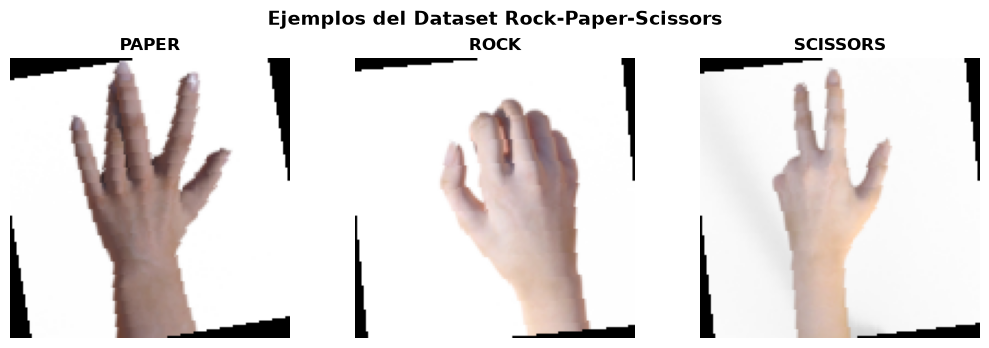

In [33]:
fig, axes = plt.subplots(1, num_clases, figsize=(num_clases * 3.5, 3.5), dpi=100)

targets = np.array(train_data.targets)

mean_t = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
std_t  = torch.tensor(std,  dtype=torch.float32).view(3, 1, 1)

for i, clase in enumerate(clases):
    idx = np.where(targets == i)[0][0]
    img, _ = train_data[idx]

    img_vis = (img * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()

    axes[i].imshow(img_vis)
    axes[i].set_title(clase.upper(), fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Ejemplos del Dataset Rock-Paper-Scissors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
model = nn.Sequential(
    nn.Flatten(),

    nn.Linear(input_dim, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, num_clases)
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal de parámetros entrenables: {total_params:,}')

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=49152, out_features=512, bias=True)
  (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=512, out_features=256, bias=True)
  (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=256, out_features=3, bias=True)
)

Total de parámetros entrenables: 25,299,971


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4) #l2
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

mejor_loss  = float('inf')
sin_mejora  = 0
mejor_epoca = 1
CHECKPOINT  = 'mejor_modelo.pt'

print('Iniciando entrenamiento...\n')

for epoca in range(1, EPOCHS + 1):
    model.train()
    loss_train, preds_train, real_train = 0.0, [], []

    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        salida = model(X_b)
        loss   = criterion(salida, y_b)
        loss.backward()
        optimizer.step()

        loss_train  += loss.item() * len(y_b)
        preds_train += salida.argmax(1).cpu().tolist()
        real_train  += y_b.cpu().tolist()

    model.eval()
    loss_test, preds_test, real_test = 0.0, [], []

    with torch.no_grad():
        for X_b, y_b in test_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            salida    = model(X_b)
            loss_test += criterion(salida, y_b).item() * len(y_b)
            preds_test += salida.argmax(1).cpu().tolist()
            real_test  += y_b.cpu().tolist()

    scheduler.step()

    avg_train = loss_train / len(train_data)
    avg_test  = loss_test  / len(test_data)
    acc_train = accuracy_score(real_train, preds_train)
    acc_test  = accuracy_score(real_test,  preds_test)

    train_losses.append(avg_train);  test_losses.append(avg_test)
    train_accs.append(acc_train);    test_accs.append(acc_test)

    if avg_test < mejor_loss:
        mejor_loss  = avg_test
        mejor_epoca = epoca
        sin_mejora  = 0
        torch.save(model.state_dict(), CHECKPOINT)
        estado_guardado = ' [Guardado ✓]'
    else:
        sin_mejora += 1
        estado_guardado = f' [Sin mejora: {sin_mejora}/{PATIENCE}]'

    print(f'Época {epoca:2d}/{EPOCHS} | '
          f'Train Loss: {avg_train:.4f} ({acc_train*100:.1f}%) | '
          f'Test Loss: {avg_test:.4f} ({acc_test*100:.1f}%)'
          f'{estado_guardado}')

    if sin_mejora >= PATIENCE:
        print(f'\n-> Early Stopping activado en época {epoca}.')
        break

model.load_state_dict(torch.load(CHECKPOINT, weights_only=True, map_location=device))
model.eval()
print(f'\nMejor modelo restaurado (Época {mejor_epoca} - Test Loss: {mejor_loss:.4f})')

Iniciando entrenamiento...

Época  1/100 | Train Loss: 0.7749 (65.5%) | Test Loss: 0.7892 (68.5%) [Guardado ✓]
Época  2/100 | Train Loss: 0.3044 (89.4%) | Test Loss: 0.6579 (71.8%) [Guardado ✓]
Época  3/100 | Train Loss: 0.1944 (94.0%) | Test Loss: 0.8090 (76.6%) [Sin mejora: 1/8]
Época  4/100 | Train Loss: 0.1419 (95.6%) | Test Loss: 0.5718 (82.3%) [Guardado ✓]
Época  5/100 | Train Loss: 0.1319 (95.4%) | Test Loss: 0.8461 (71.5%) [Sin mejora: 1/8]
Época  6/100 | Train Loss: 0.1239 (95.8%) | Test Loss: 0.5569 (84.1%) [Guardado ✓]
Época  7/100 | Train Loss: 0.1308 (95.3%) | Test Loss: 0.7453 (80.1%) [Sin mejora: 1/8]
Época  8/100 | Train Loss: 0.1303 (95.6%) | Test Loss: 0.9565 (71.8%) [Sin mejora: 2/8]
Época  9/100 | Train Loss: 0.0954 (96.6%) | Test Loss: 1.1048 (69.1%) [Sin mejora: 3/8]
Época 10/100 | Train Loss: 0.1143 (96.1%) | Test Loss: 1.0179 (72.6%) [Sin mejora: 4/8]
Época 11/100 | Train Loss: 0.0685 (97.4%) | Test Loss: 0.9482 (72.8%) [Sin mejora: 5/8]
Época 12/100 | Train Los

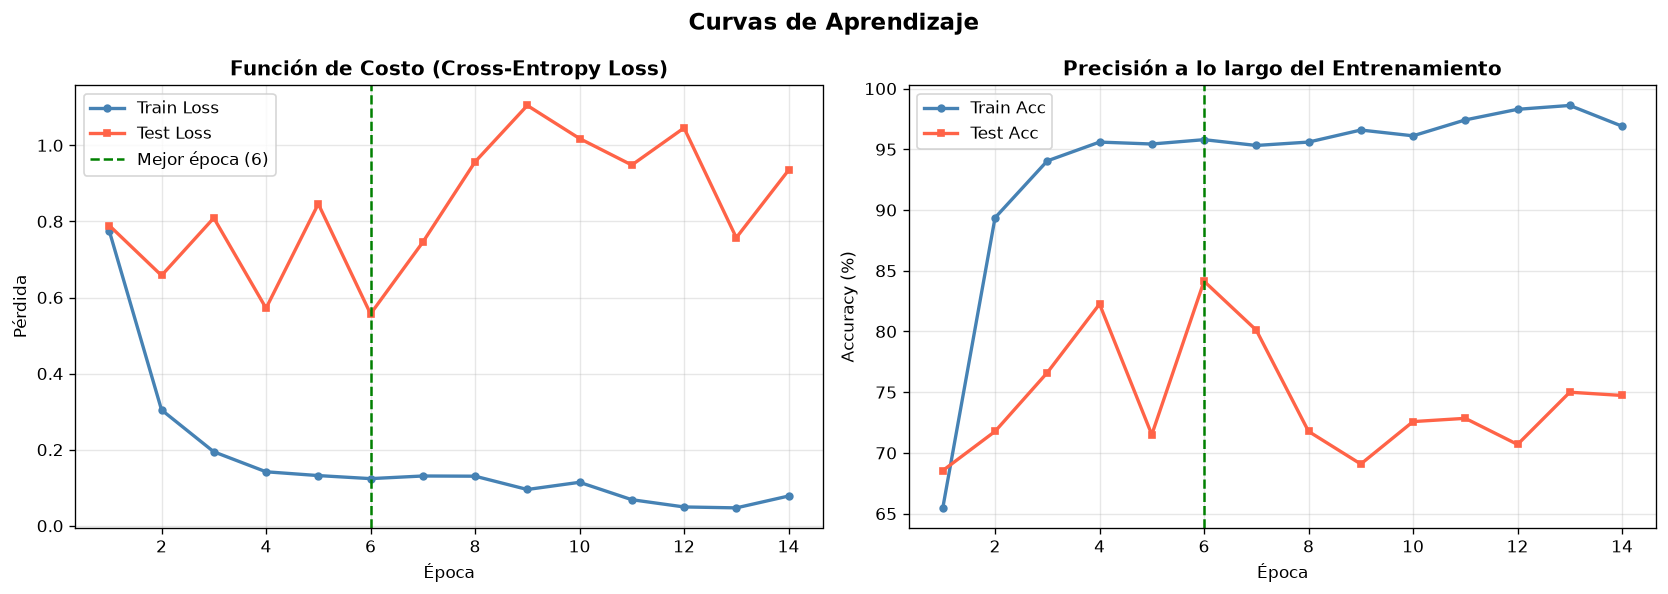

In [36]:
epocas = list(range(1, len(train_losses) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

ax1.plot(epocas, train_losses, label='Train Loss', color='steelblue', lw=2, marker='o', ms=4)
ax1.plot(epocas, test_losses,  label='Test Loss',  color='tomato',    lw=2, marker='s', ms=4)
ax1.axvline(x=mejor_epoca, color='green', linestyle='--', label=f'Mejor época ({mejor_epoca})')
ax1.set_title('Función de Costo (Cross-Entropy Loss)', fontweight='bold')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epocas, [a * 100 for a in train_accs], label='Train Acc', color='steelblue', lw=2, marker='o', ms=4)
ax2.plot(epocas, [a * 100 for a in test_accs],  label='Test Acc',  color='tomato',    lw=2, marker='s', ms=4)
ax2.axvline(x=mejor_epoca, color='green', linestyle='--')
ax2.set_title('Precisión a lo largo del Entrenamiento', fontweight='bold')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
model.eval()
todas_preds, todas_real = [], []

with torch.no_grad():
    for X_b, y_b in test_loader:
        salida = model(X_b.to(device))
        todas_preds += salida.argmax(1).cpu().tolist()
        todas_real  += y_b.tolist()

todas_preds = np.array(todas_preds)
todas_real  = np.array(todas_real)

acc  = accuracy_score(todas_real, todas_preds)
prec = precision_score(todas_real, todas_preds, average='macro', zero_division=0)
rec  = recall_score(todas_real, todas_preds, average='macro', zero_division=0)
f1   = f1_score(todas_real, todas_preds, average='macro', zero_division=0)

print('=' * 50)
print('  REPORTE GLOBAL DE RENDIMIENTO (Test Set)')
print('=' * 50)
print(f'  Accuracy  (Exactitud)    : {acc * 100:.2f}%')
print(f'  Precision (Precisión)    : {prec * 100:.2f}%')
print(f'  Recall    (Exhaustividad): {rec * 100:.2f}%')
print(f'  F1-Score                 : {f1 * 100:.2f}%')
print('=' * 50)

print('\nExactitud desglosada por clase:')
cm = confusion_matrix(todas_real, todas_preds)
for i, cls in enumerate(clases):
    correcto = cm[i, i]
    total    = cm[i].sum()
    pct      = (100.0 * correcto / total) if total > 0 else 0.0
    print(f'  {cls:>10s}: {correcto:3d}/{total:3d} ({pct:5.1f}%)')

  REPORTE GLOBAL DE RENDIMIENTO (Test Set)
  Accuracy  (Exactitud)    : 84.14%
  Precision (Precisión)    : 86.70%
  Recall    (Exhaustividad): 84.14%
  F1-Score                 : 83.41%

Exactitud desglosada por clase:
       paper: 115/124 ( 92.7%)
        rock:  76/124 ( 61.3%)
    scissors: 122/124 ( 98.4%)


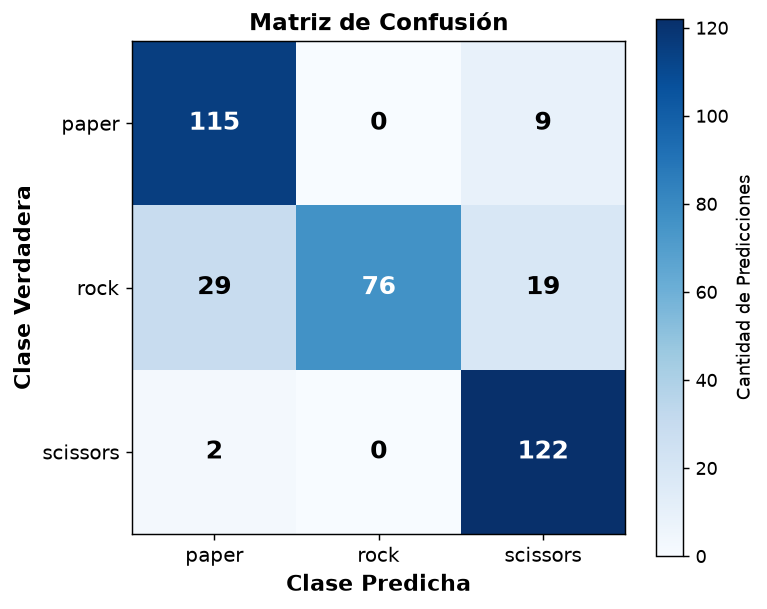

In [38]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=130)

im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Cantidad de Predicciones')

ax.set_xticks(range(num_clases))
ax.set_xticklabels(clases, fontsize=11)
ax.set_yticks(range(num_clases))
ax.set_yticklabels(clases, fontsize=11)
ax.set_xlabel('Clase Predicha', fontsize=12, fontweight='bold')
ax.set_ylabel('Clase Verdadera', fontsize=12, fontweight='bold')
ax.set_title('Matriz de Confusión', fontsize=13, fontweight='bold')

umbral = cm.max() / 2.0
for i in range(num_clases):
    for j in range(num_clases):
        color = 'white' if cm[i, j] > umbral else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=14, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

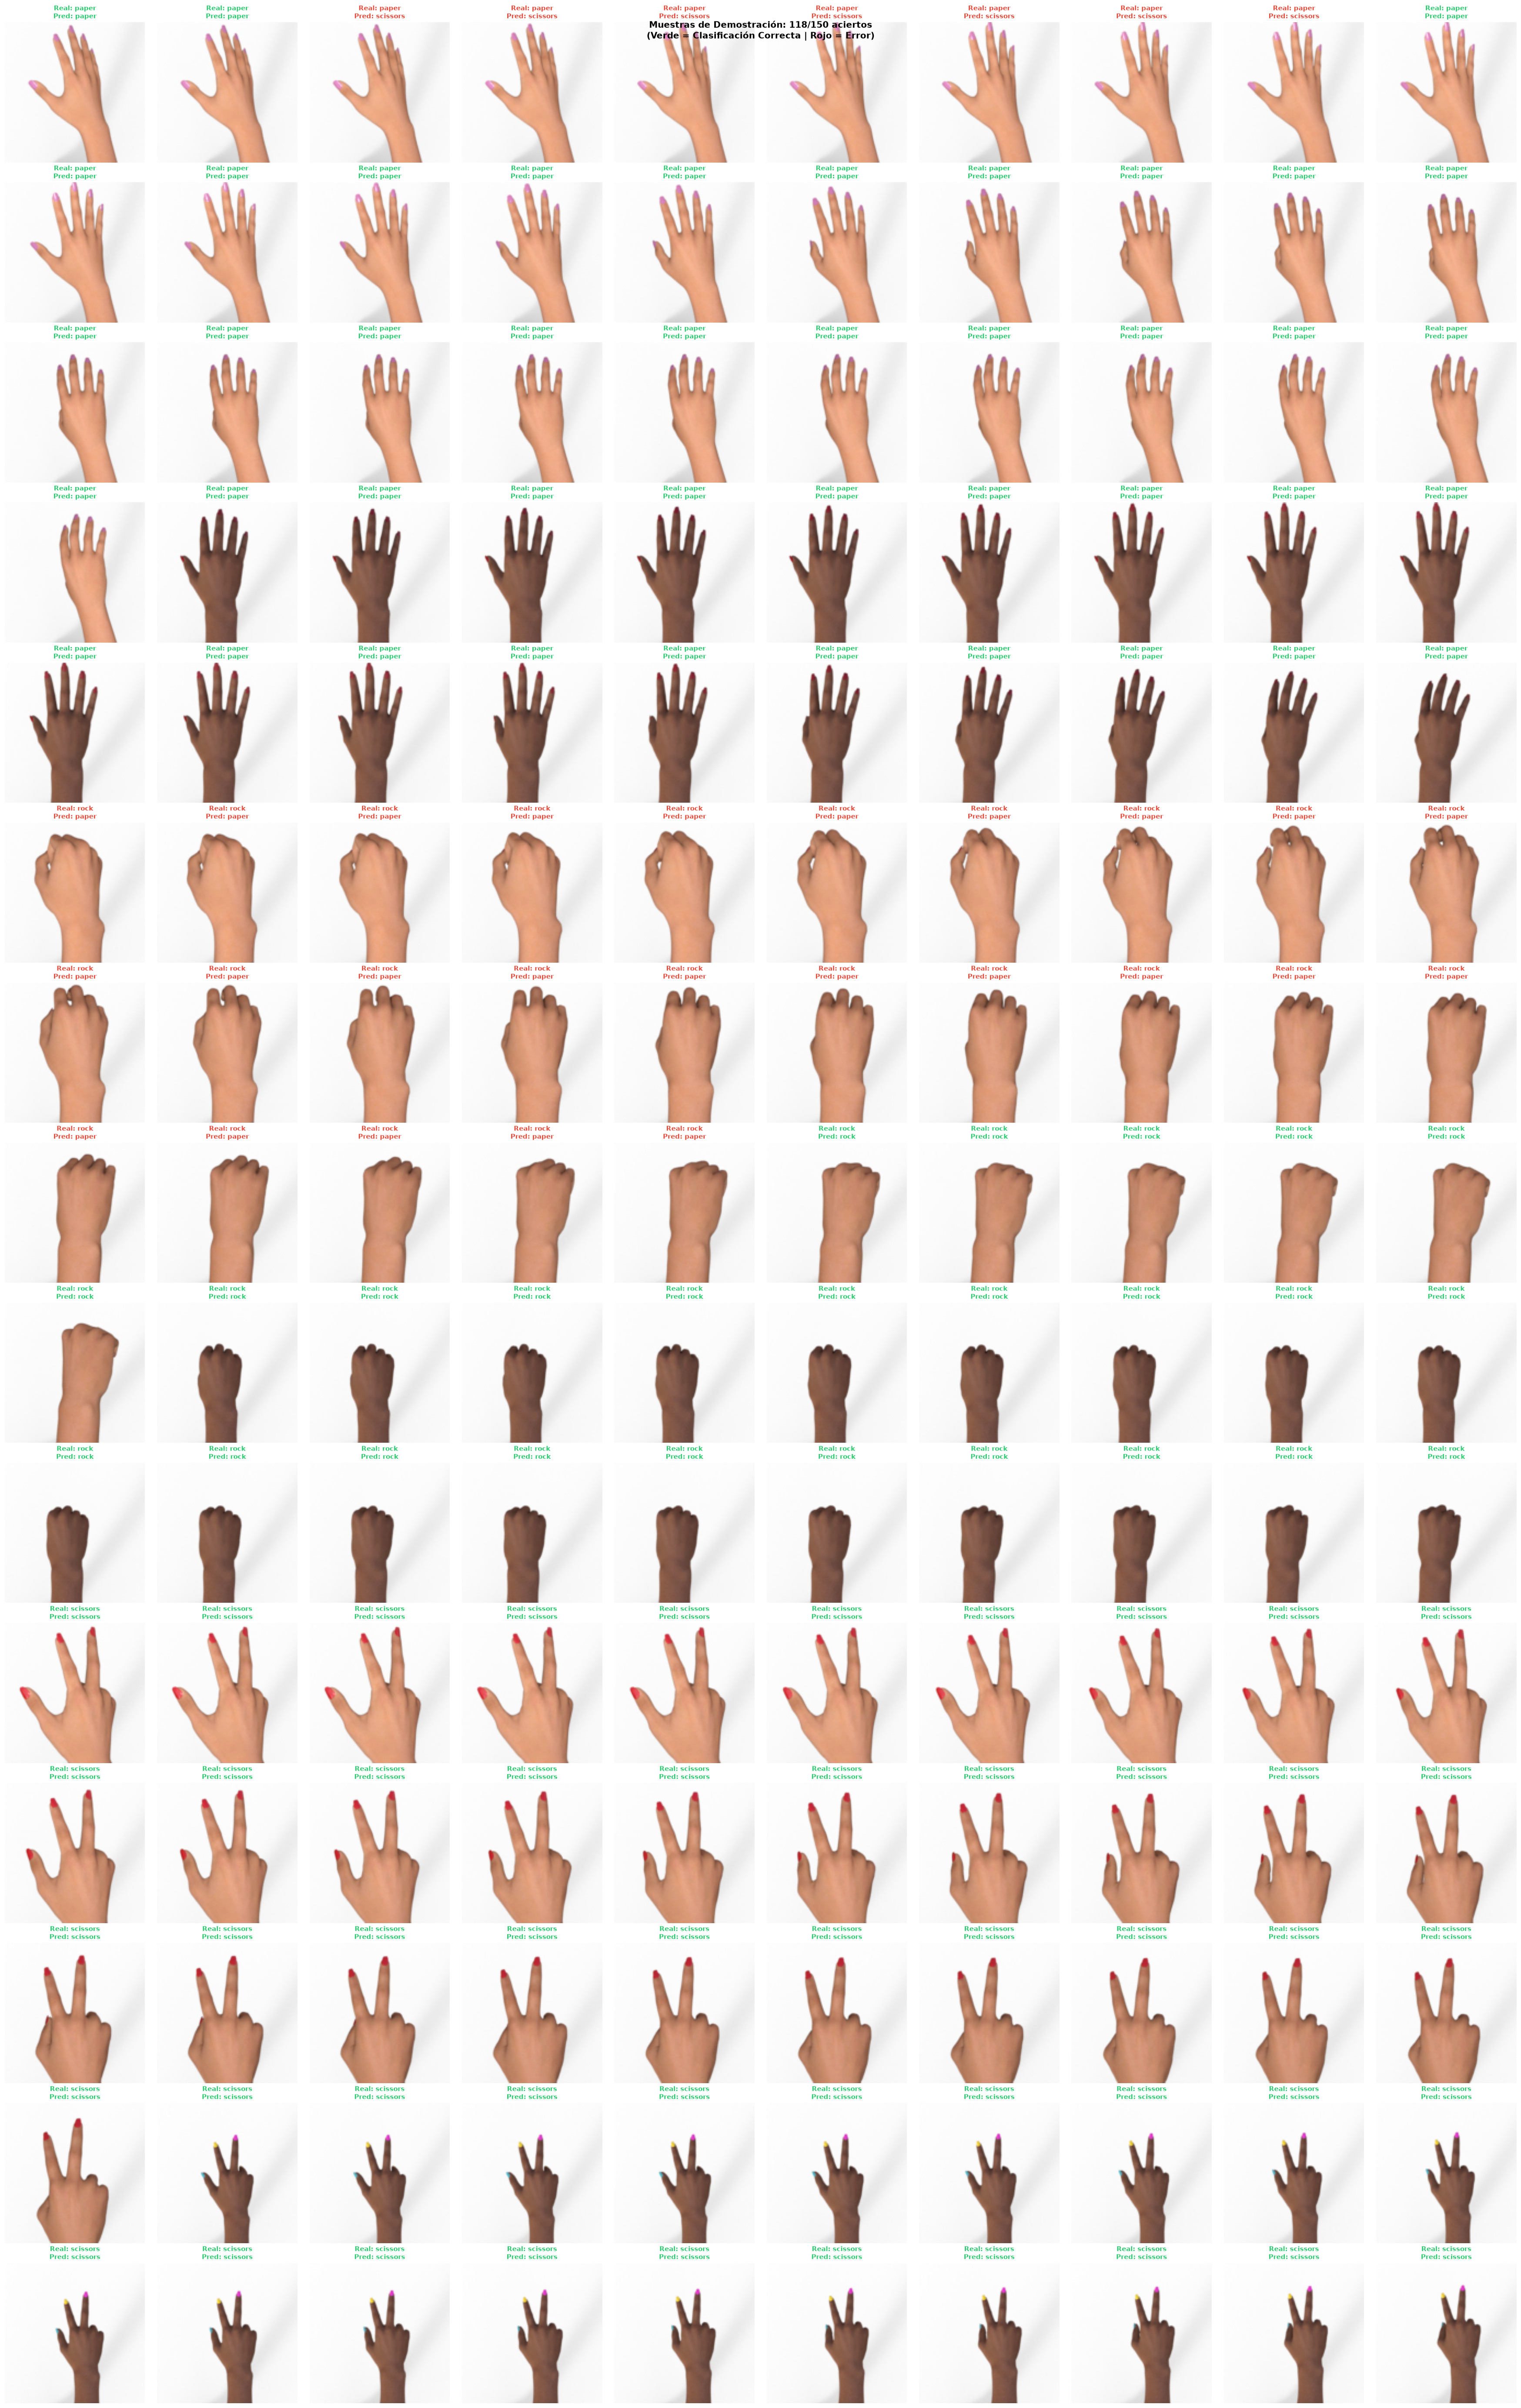

In [39]:
targets_test = np.array(test_data.targets)
indices = []

for c in range(num_clases):
    idx_clase = np.where(targets_test == c)[0][:50]
    indices.extend(idx_clase.tolist())

imagenes  = torch.stack([test_data[i][0] for i in indices]).to(device)
etiquetas = [test_data[i][1] for i in indices]

model.eval()
with torch.no_grad():
    predicciones = model(imagenes).argmax(1).cpu().tolist()

n_cols = 10
n_rows = math.ceil(len(indices) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 3.4), dpi=110)
axes = np.array(axes).reshape(-1)

for k, idx in enumerate(indices):
    img = test_data[idx][0]
    img_vis = (img * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()

    real  = clases[etiquetas[k]]
    pred  = clases[predicciones[k]]
    color = '#2ecc71' if real == pred else '#e74c3c'

    axes[k].imshow(img_vis)
    axes[k].set_title(f'Real: {real}\nPred: {pred}',
                      color=color, fontsize=10, fontweight='bold')
    for spine in axes[k].spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    axes[k].axis('off')

for ax in axes[len(indices):]:
    ax.axis('off')

aciertos = sum(p == r for p, r in zip(predicciones, etiquetas))
plt.suptitle(f'Muestras de Demostración: {aciertos}/{len(indices)} aciertos\n'
             f'(Verde = Clasificación Correcta | Rojo = Error)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()